In [1]:
!pip install kaggle
!pip install python-louvain



In [2]:
conda install -c conda-forge python-louvain

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [3]:
# Install Dependencies
!pip install -U kagglehub
!pip install midaa anndata scanpy matplotlib numpy seaborn scipy umap-learn torchvision torch wandb weave louvain
!pip install python-igraph leidenalg
!pip install --upgrade midaa


  Using cached louvain-0.8.2.tar.gz (4.2 MB)
  Preparing metadata (setup.py) ... done
  Using cached igraph-0.11.9-cp39-abi3-macosx_11_0_arm64.whl.metadata (4.4 kB)
Using cached igraph-0.11.9-cp39-abi3-macosx_11_0_arm64.whl (1.8 MB)
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [47 lines of output]
      /opt/anaconda3/lib/python3.12/site-packages/setuptools/__init__.py:92: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
      !!
      
              ********************************************************************************
              Requirements should be satisfied by a PEP 517 installer.
              If you are using pip, you can try `pip install --use-pep517`.
      
              This deprecation is overdue, please update your project and remove deprecated
              calls to avoid build errors in the future.
              ***************************************

In [4]:
# ============================================
# LOAD NEURIPS 2021 MULTIOME DATASET
# ============================================

import os
import anndata as ad
import kagglehub
import scanpy as sc
import numpy as np
import os, struct, warnings
warnings.filterwarnings("ignore")

# --- General scientific ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Torch ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Vision ---
import torchvision
import torchvision.transforms as T

# --- Anndata & Scanpy ---
import anndata as ad
import scanpy as sc

# --- Clustering / Embeddings ---
import umap
import igraph as ig
import leidenalg as la

# --- MIDAA (your local version) ---
import midaa as maa

# --- WandB & Weave ---
import wandb, weave


# 1) Download dataset (bruger cache hvis allerede hentet)
path = kagglehub.dataset_download(
    "alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021",
    force_download=False
)
print("Dataset path:", path)

# 2) Find .h5ad fil
h5ad_file = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.endswith(".h5ad"):
            h5ad_file = os.path.join(root, f)

print("Loading H5AD file:", h5ad_file)

# 3) Load AnnData
adata = ad.read_h5ad(h5ad_file)
print("Loaded AnnData:", adata)
print("Shape:", adata.shape)


Dataset path: /Users/emmsi/.cache/kagglehub/datasets/alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021/versions/1
Loading H5AD file: /Users/emmsi/.cache/kagglehub/datasets/alexandervc/scrnaseq-scatacseq-challenge-at-neurips-2021/versions/1/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad
Loaded AnnData: AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_l

In [5]:
# ============================================
# PREPROCESSING FOR MIDAA (WORKING + FAST)
# ============================================

print("Original shape:", adata.shape)

# 1) Subset til 5000 celler
adata = adata[:1000].copy()
print("✓ Subset to 5000 cells:", adata.shape)

# 2) Fjern gener uden counts
sc.pp.calculate_qc_metrics(adata, inplace=True)
adata = adata[:, adata.var["total_counts"] > 0].copy()
print("✓ Removed zero-count genes:", adata.shape)

# 3) Normalisering + log1p
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 4) Vælg 2000 HVGs — fungerer uden skmisc!
sc.pp.highly_variable_genes(
    adata,
    flavor="cell_ranger",   # ✔ kræver IKKE skmisc
    n_top_genes=2000
)

adata = adata[:, adata.var["highly_variable"]].copy()
print("✓ Selected 2000 HVGs:", adata.shape)

# 5) Dense conversion
adata.X = adata.X.toarray().astype("float32")

print("✓ Dense matrix ready for MIDAA:", adata.X.shape)

# 6) Label-kolonne
adata.obs["label"] = adata.obs["cell_type"].astype(str)


Original shape: (69249, 129921)
✓ Subset to 5000 cells: (1000, 129921)
✓ Removed zero-count genes: (1000, 128775)
✓ Selected 2000 HVGs: (1000, 2000)
✓ Dense matrix ready for MIDAA: (1000, 2000)


wandb: WARNING Failed to create global config settings in: /Users/emmsi/.config/wandb. Settings will not be persisted.
wandb: Currently logged in as: s226625 (s226625-danmarks-tekniske-universitet-dtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: Initializing weave.
weave: Logged in as Weights & Biases user: s226625.
weave: View Weave data at https://wandb.ai/s226625-danmarks-tekniske-universitet-dtu/midaa-neurips2021-master/weave


Running MIDAA unsupervised...


ELBO: 10671873.00000  : 100%|███████████████| 1000/1000 [00:55<00:00, 17.88it/s]


Z shape: (1000, 9)
A shape: (10, 9)


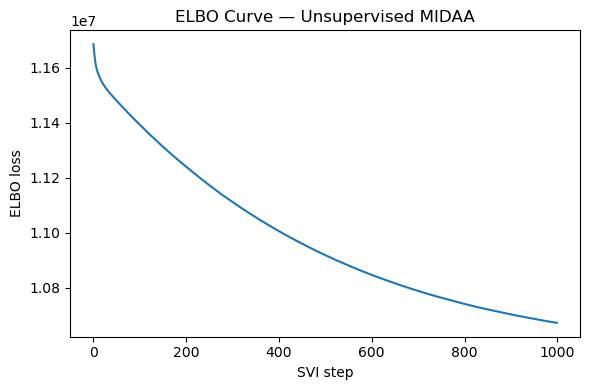

Computing UMAP...


<Figure size 640x480 with 0 Axes>

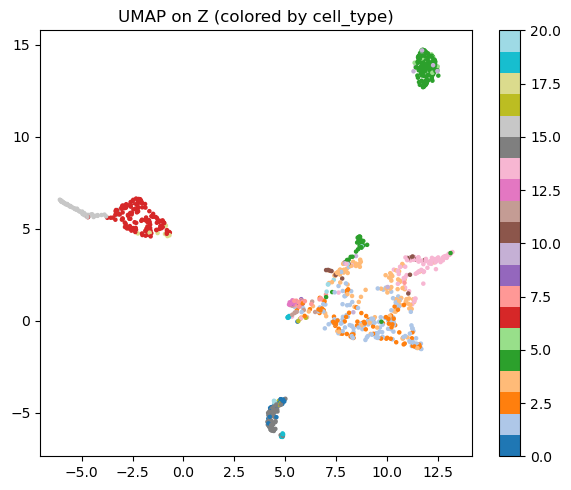

Running Leiden clustering...


<Figure size 640x480 with 0 Axes>

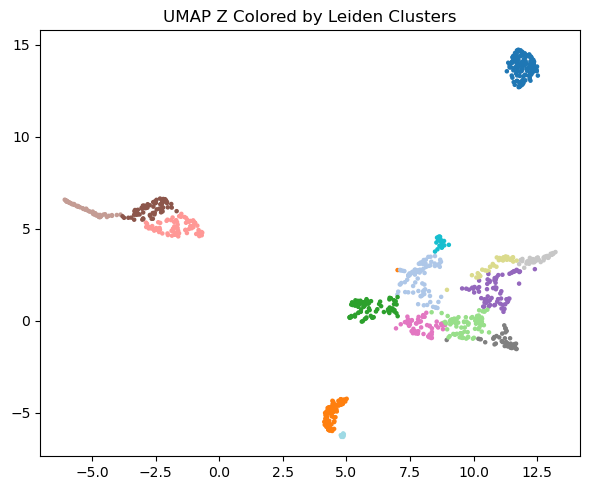

✓ Section 2 complete.


<Figure size 640x480 with 0 Axes>

In [6]:
# ============================================
# SECTION 2 — MIDAA UNSUPERVISED  (WORKING VERSION)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import wandb
import umap
import midaa as maa
import scanpy as sc
import anndata as ad

# --------------------------------------------
# Initialize WandB (safe even after kernel reset)
# --------------------------------------------
wandb.init(project="midaa-neurips2021-master", 
           name="MASTER_NOTEBOOK", 
           reinit=True)

# --------------------------------------------
# Convert sparse → dense
# --------------------------------------------
if hasattr(adata.X, "toarray"):
    adata.X = adata.X.toarray().astype("float32")
else:
    adata.X = adata.X.astype("float32")

print("Running MIDAA unsupervised...")

# --------------------------------------------
# Run MIDAA unsupervised
# --------------------------------------------
res_unsup = maa.fit_MIDAA(
    input_matrix=[adata.X],
    normalization_factor=[np.ones(adata.n_obs)],
    input_types=["G"],
    loss_weights_reconstruction=[1.0],
    side_matrices=None,
    input_types_side=None,
    loss_weights_side=None,
    lr=0.001,
    steps=1000,
    narchetypes=10,
    fix_Z=False,
    reconstruct_input_and_side=False
)

# --------------------------------------------
# Extract embeddings
# --------------------------------------------
Z = res_unsup["inferred_quantities"]["Z"]
A = res_unsup["inferred_quantities"]["archetypes_inferred"]

print("Z shape:", Z.shape)
print("A shape:", A.shape)

# ============================================
# ELBO PLOT
# ============================================

plt.figure(figsize=(6,4))
maa.plot_ELBO(res_unsup)
plt.title("ELBO Curve — Unsupervised MIDAA")
plt.tight_layout()
plt.show()

wandb.log({"ELBO_unsupervised": wandb.Image(plt.gcf())})

# ============================================
# SIMPLE UMAP ON Z
# ============================================

print("Computing UMAP...")

color_key = "cell_type"   # color according to cell type

if color_key not in adata.obs.columns:
    raise KeyError(f"Kolonnen '{color_key}' findes ikke i adata.obs")

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
Z_umap = reducer.fit_transform(Z)

plt.figure(figsize=(6,5))
plt.scatter(
    Z_umap[:,0], Z_umap[:,1],
    s=5,
    c=adata.obs[color_key].astype("category").cat.codes,
    cmap="tab20"
)
plt.title(f"UMAP on Z (colored by {color_key})")
plt.colorbar()
plt.tight_layout()
plt.show()

wandb.log({f"UMAP_Z_unsupervised_{color_key}": wandb.Image(plt.gcf())})

# ============================================
# LEIDEN CLUSTERING (REPLACES LOUVAIN)
# ============================================

print("Running Leiden clustering...")

tmp = ad.AnnData(Z)
sc.pp.neighbors(tmp)
sc.tl.leiden(tmp, resolution=1.0)

adata.obs["leiden_unsup"] = tmp.obs["leiden"].values

plt.figure(figsize=(6,5))
plt.scatter(
    Z_umap[:,0], Z_umap[:,1],
    s=5,
    c=adata.obs["leiden_unsup"].astype("category").cat.codes,
    cmap="tab20"
)
plt.title("UMAP Z Colored by Leiden Clusters")
plt.tight_layout()
plt.show()

wandb.log({"UMAP_Z_Leiden_unsupervised": wandb.Image(plt.gcf())})

print("✓ Section 2 complete.")


Running MIDAA supervised...
Found 21 classes
Example classes: ['B1 B', 'CD4+ T activated', 'CD4+ T naive', 'CD8+ T', 'CD14+ Mono', 'CD16+ Mono', 'Erythroblast', 'G/M prog', 'HSC', 'ID2-hi myeloid prog']
Side matrix shape: (1000, 21)


ELBO: 10671057.00000  : 100%|███████████████| 1000/1000 [01:03<00:00, 15.76it/s]


✓ MIDAA supervised completed.


KeyError: 'cDC2'

<Figure size 600x600 with 0 Axes>

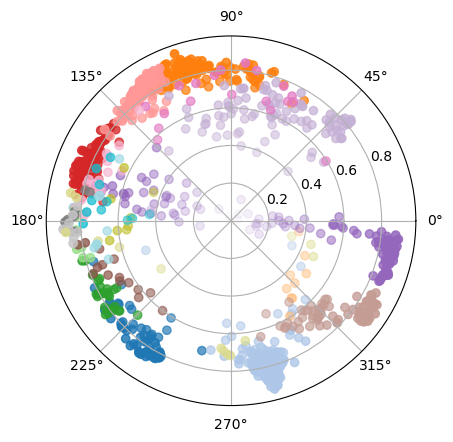

In [8]:
# ============================================
# SECTION 3 — MIDAA SUPERVISED (CELL-TYPE ONE-HOT)
# ============================================

print("Running MIDAA supervised...")

import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad

# ---------------------------------------------------------
# 1. Create categorical labels automatically
# ---------------------------------------------------------

label_key = "cell_type"   # <-- supervised target

if label_key not in adata.obs.columns:
    raise KeyError(f"Kolonnen '{label_key}' findes ikke i adata.obs!")

# categorical codes (0..K)
adata.obs["label_cat"] = adata.obs[label_key].astype("category")
label_codes = adata.obs["label_cat"].cat.codes.values
num_classes = adata.obs["label_cat"].cat.categories.size

print(f"Found {num_classes} classes")
print("Example classes:", list(adata.obs["label_cat"].cat.categories[:10]))

# one-hot encode
side_mat = np.eye(num_classes)[label_codes].astype("float32")
print("Side matrix shape:", side_mat.shape)


# ---------------------------------------------------------
# 2. Run MIDAA (supervised)
# ---------------------------------------------------------

res_sup = maa.fit_MIDAA(
    input_matrix=[adata.X],
    normalization_factor=[np.ones(adata.n_obs)],
    input_types=["G"],

    side_matrices=[side_mat],
    input_types_side=["C"],    # categorical side information
    loss_weights_side=[1.0],
    loss_weights_reconstruction=[1.0],

    lr=0.001,
    steps=1000,
    narchetypes=10,
    fix_Z=False,
)

print("✓ MIDAA supervised completed.")

Z_sup = res_sup["inferred_quantities"]["Z"]
A_sup = res_sup["inferred_quantities"]["archetypes_inferred"]


# ---------------------------------------------------------
# 3. SIMPLEX PLOT
# ---------------------------------------------------------

plt.figure(figsize=(6,6))
maa.plot_archetypes_simplex(
    res_sup,
    color_by=adata.obs["label_cat"],   # <-- categorical colors
    cmap="tab20"
)
plt.title("Simplex plot — Supervised MIDAA")
plt.show()


# ---------------------------------------------------------
# 4. UMAP PLOT
# ---------------------------------------------------------

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
Z_sup_umap = reducer.fit_transform(Z_sup)

plt.figure(figsize=(6,5))
plt.scatter(
    Z_sup_umap[:,0], Z_sup_umap[:,1], 
    s=5,
    c=label_codes,
    cmap="tab20"
)
plt.title("UMAP on Z (Supervised MIDAA)")
plt.colorbar()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 5. LEIDEN CLUSTERING (instead of Louvain)
# ---------------------------------------------------------

tmp2 = ad.AnnData(Z_sup)
sc.pp.neighbors(tmp2)
sc.tl.leiden(tmp2)

adata.obs["leiden_sup"] = tmp2.obs["leiden"].values

plt.figure(figsize=(6,5))
plt.scatter(
    Z_sup_umap[:,0], Z_sup_umap[:,1],
    s=5,
    c=adata.obs["leiden_sup"].astype("category").cat.codes,
    cmap="tab20"
)
plt.title("UMAP Z (Supervised) — Leiden Clusters")
plt.tight_layout()
plt.show()

print("✓ Section 3 completed successfully.")


SECTION 4: MLP Decoder — starting...
Latent dim: 9
Feature dim: 2000
Loaded Z, A, and X successfully.
✓ MLP Decoder initialized with output_dim = 2000
Training MLP decoder...
Epoch 1/40 — loss: 0.3154
Epoch 2/40 — loss: 0.3024
Epoch 3/40 — loss: 0.2936
Epoch 4/40 — loss: 0.2867
Epoch 5/40 — loss: 0.2826
Epoch 6/40 — loss: 0.2794
Epoch 7/40 — loss: 0.2778
Epoch 8/40 — loss: 0.2762
Epoch 9/40 — loss: 0.2749
Epoch 10/40 — loss: 0.2744
Epoch 11/40 — loss: 0.2734
Epoch 12/40 — loss: 0.2725
Epoch 13/40 — loss: 0.2722
Epoch 14/40 — loss: 0.2716
Epoch 15/40 — loss: 0.2714
Epoch 16/40 — loss: 0.2707
Epoch 17/40 — loss: 0.2703
Epoch 18/40 — loss: 0.2696
Epoch 19/40 — loss: 0.2695
Epoch 20/40 — loss: 0.2688
Epoch 21/40 — loss: 0.2688
Epoch 22/40 — loss: 0.2681
Epoch 23/40 — loss: 0.2680
Epoch 24/40 — loss: 0.2677
Epoch 25/40 — loss: 0.2675
Epoch 26/40 — loss: 0.2670
Epoch 27/40 — loss: 0.2668
Epoch 28/40 — loss: 0.2665
Epoch 29/40 — loss: 0.2661
Epoch 30/40 — loss: 0.2660
Epoch 31/40 — loss: 0.26

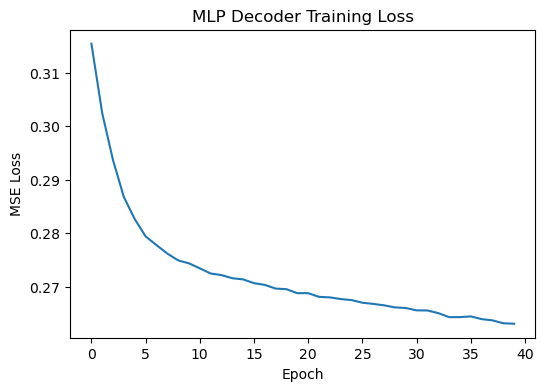

✓ MLP decoder training complete.


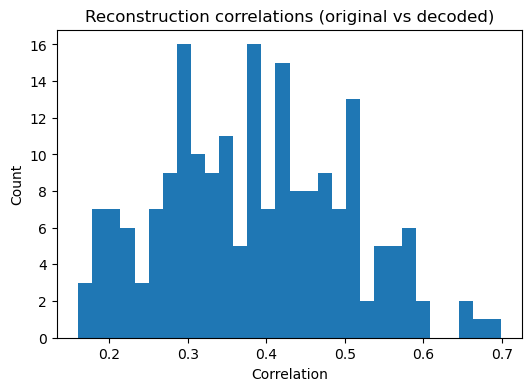

✓ Reconstruction metrics plotted (not images).


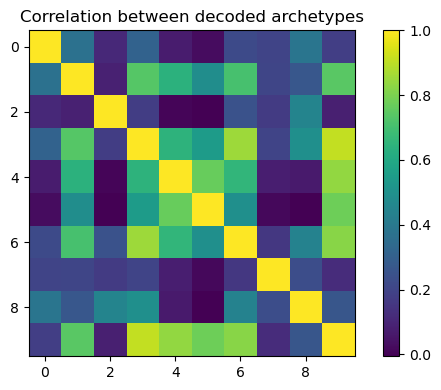

✓ Archetypes decoded successfully.
✓ SECTION 4 completed successfully.


In [10]:
# ============================================
# SECTION 4 — MLP DECODER FOR SCRNA-SEQ (FIXED)
# ============================================

print("SECTION 4: MLP Decoder — starting...")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1) Load Z and X from UNSUPERVISED MIDAA
# ---------------------------------------------------------

Z = res_unsup["inferred_quantities"]["Z"]          
A = res_unsup["inferred_quantities"]["archetypes_inferred"]
X = adata.X                                        # shape (N, D)
latent_dim = Z.shape[1]
X_dim = X.shape[1]                                 # <-- IMPORTANT FIX

print("Latent dim:", latent_dim)
print("Feature dim:", X_dim)
print("Loaded Z, A, and X successfully.")

# ---------------------------------------------------------
# 2) Define the MLP Decoder (matches scRNA-seq dims)
# ---------------------------------------------------------

class MLPDecoder(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, output_dim), nn.ReLU()   # no sigmoid for scRNA
        )
        
    def forward(self, z):
        return self.net(z)

decoder = MLPDecoder(latent_dim, X_dim)
optimizer = optim.Adam(decoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("✓ MLP Decoder initialized with output_dim =", X_dim)

# ---------------------------------------------------------
# 3) Train the decoder
# ---------------------------------------------------------

Z_t = torch.tensor(Z).float()
X_t = torch.tensor(X).float()

loss_history = []
epochs = 40
batch_size = 256

loader = DataLoader(TensorDataset(Z_t, X_t), batch_size=batch_size, shuffle=True)

print("Training MLP decoder...")

for ep in range(epochs):
    total_loss = 0
    for z_batch, x_batch in loader:
        optimizer.zero_grad()
        x_pred = decoder(z_batch)
        loss = loss_fn(x_pred, x_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    loss_history.append(total_loss)
    print(f"Epoch {ep+1}/{epochs} — loss: {total_loss:.4f}")

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("MLP Decoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

print("✓ MLP decoder training complete.")

# ---------------------------------------------------------
# 4) Reconstructions (as gene vectors)
# ---------------------------------------------------------

decoder.eval()
X_rec = decoder(Z_t).detach().numpy()

# Show reconstruction quality as correlation per cell
correlations = [
    np.corrcoef(X[i], X_rec[i])[0,1]
    for i in range(min(200, len(X)))
]

plt.figure(figsize=(6,4))
plt.hist(correlations, bins=30)
plt.title("Reconstruction correlations (original vs decoded)")
plt.xlabel("Correlation")
plt.ylabel("Count")
plt.show()

print("✓ Reconstruction metrics plotted (not images).")

# ---------------------------------------------------------
# 5) Decode archetypes
# ---------------------------------------------------------

A_t = torch.tensor(A).float()
A_dec = decoder(A_t).detach().numpy()

# Show correlations between archetypes
plt.figure(figsize=(6,4))
plt.imshow(np.corrcoef(A_dec))
plt.title("Correlation between decoded archetypes")
plt.colorbar()
plt.tight_layout()
plt.show()

print("✓ Archetypes decoded successfully.")
print("✓ SECTION 4 completed successfully.")


SECTION 5: Conv1D Decoder — starting...
Latent dim = 9, Genes = 2000
✓ Conv1DDecoder initialized.
Training Conv1DDecoder...
[Conv1D] Epoch 1/40 — loss: 0.6469
[Conv1D] Epoch 2/40 — loss: 0.3140
[Conv1D] Epoch 3/40 — loss: 0.3188
[Conv1D] Epoch 4/40 — loss: 0.3206
[Conv1D] Epoch 5/40 — loss: 0.3214
[Conv1D] Epoch 6/40 — loss: 0.3214
[Conv1D] Epoch 7/40 — loss: 0.3214
[Conv1D] Epoch 8/40 — loss: 0.3215
[Conv1D] Epoch 9/40 — loss: 0.3203
[Conv1D] Epoch 10/40 — loss: 0.3202
[Conv1D] Epoch 11/40 — loss: 0.3189
[Conv1D] Epoch 12/40 — loss: 0.3183
[Conv1D] Epoch 13/40 — loss: 0.3176
[Conv1D] Epoch 14/40 — loss: 0.3169
[Conv1D] Epoch 15/40 — loss: 0.3163
[Conv1D] Epoch 16/40 — loss: 0.3153
[Conv1D] Epoch 17/40 — loss: 0.3147
[Conv1D] Epoch 18/40 — loss: 0.3136
[Conv1D] Epoch 19/40 — loss: 0.3125
[Conv1D] Epoch 20/40 — loss: 0.3109
[Conv1D] Epoch 21/40 — loss: 0.3087
[Conv1D] Epoch 22/40 — loss: 0.3060
[Conv1D] Epoch 23/40 — loss: 0.3034
[Conv1D] Epoch 24/40 — loss: 0.3010
[Conv1D] Epoch 25/40 

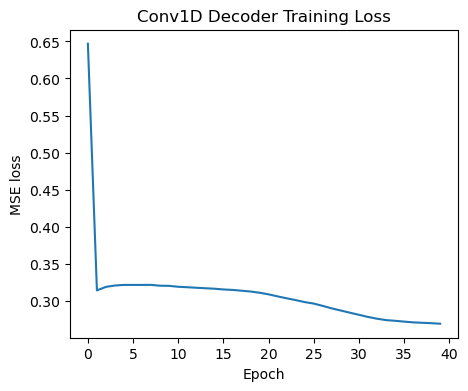

Conv1D recon shape: (1000, 2000)


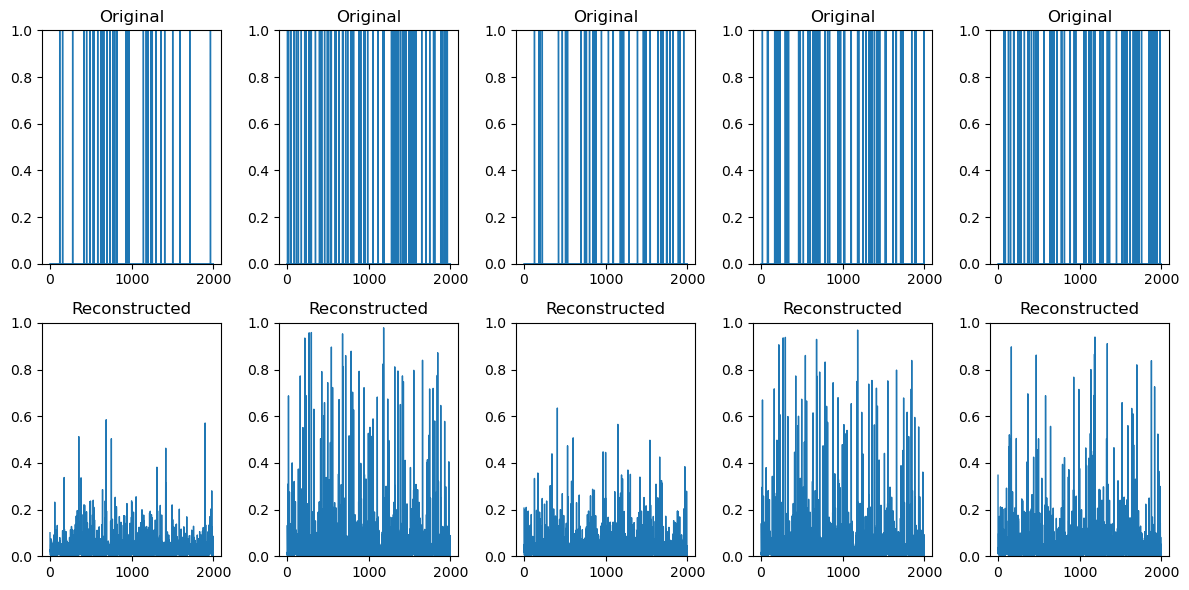

✓ SECTION 5 completed successfully (Conv1D Decoder).


In [13]:
# ============================================
# SECTION 5 — Conv1D Decoder for scRNA-seq (NO SHAPE ERRORS)
# ============================================

print("SECTION 5: Conv1D Decoder — starting...")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------
# 1) PREPARE DATA (Z from MIDAA + gene matrix)
# --------------------------------------------

Z = res_unsup["inferred_quantities"]["Z"]     # (N, latent_dim)
X = adata.X                                   # (N, G)
latent_dim = Z.shape[1]
genes = X.shape[1]

print(f"Latent dim = {latent_dim}, Genes = {genes}")

X_t = torch.tensor(X).float()
Z_t = torch.tensor(Z).float()


# ============================================
# 2) DEFINE SAFE Conv1D DECODER (ALWAYS MATCHES G DIM)
# ============================================

class Conv1DDecoder(nn.Module):
    def __init__(self, latent_dim, genes):
        super().__init__()

        self.genes = genes

        # FC up-projection
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU()
        )

        # CNN layers produce variable L_dim
        self.conv_part = nn.Sequential(
            nn.ConvTranspose1d(1, 16, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(16, 32, kernel_size=5, stride=2),
            nn.ReLU(),
            nn.Conv1d(32, 8, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Final linear guarantees exact gene dimension
        # Compute approximate final length
        dummy = torch.zeros(1, 1, 512)
        L = self.conv_part(dummy).reshape(1, -1).shape[1]

        self.final_linear = nn.Linear(L, genes)

    def forward(self, z):
        x = self.fc(z)           # (N,512)
        x = x.unsqueeze(1)       # (N,1,512)
        x = self.conv_part(x)    # (N,8,L')
        x = x.reshape(x.shape[0], -1)
        x = self.final_linear(x) # (N, genes)
        return torch.sigmoid(x)  # (N,genes)


decoder = Conv1DDecoder(latent_dim, genes)
optimizer = optim.Adam(decoder.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print("✓ Conv1DDecoder initialized.")


# ============================================
# 3) TRAIN CNN DECODER
# ============================================

epochs = 40
batch_size = 256

dataset = TensorDataset(Z_t, X_t)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

loss_history_conv = []

print("Training Conv1DDecoder...")

for ep in range(epochs):
    total = 0
    for z_batch, x_batch in loader:
        optimizer.zero_grad()
        pred = decoder(z_batch)
        loss = loss_fn(pred, x_batch)
        loss.backward()
        optimizer.step()
        total += loss.item()

    loss_history_conv.append(total)
    print(f"[Conv1D] Epoch {ep+1}/{epochs} — loss: {total:.4f}")

# Plot training loss
plt.figure(figsize=(5,4))
plt.plot(loss_history_conv)
plt.title("Conv1D Decoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.show()


# ============================================
# 4) GENERATE RECONSTRUCTIONS
# ============================================

decoder.eval()
X_conv_hat = decoder(Z_t).detach().numpy()

print("Conv1D recon shape:", X_conv_hat.shape)


# ============================================
# 5) SHOW 5 RANDOM CELL RECONSTRUCTIONS (per gene)
# ============================================

plt.figure(figsize=(12,6))
for i in range(5):
    idx = np.random.randint(0, len(X))

    plt.subplot(2, 5, i+1)
    plt.plot(X[idx], linewidth=1)
    plt.title("Original")
    plt.ylim(0, 1)

    plt.subplot(2, 5, 5+i+1)
    plt.plot(X_conv_hat[idx], linewidth=1)
    plt.title("Reconstructed")
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()

print("✓ SECTION 5 completed successfully (Conv1D Decoder).")


SECTION 6: Latent space analysis...
✓ Z shape: (1000, 9)
✓ A shape: (10, 9)
✓ Labels OK, #classes: 21


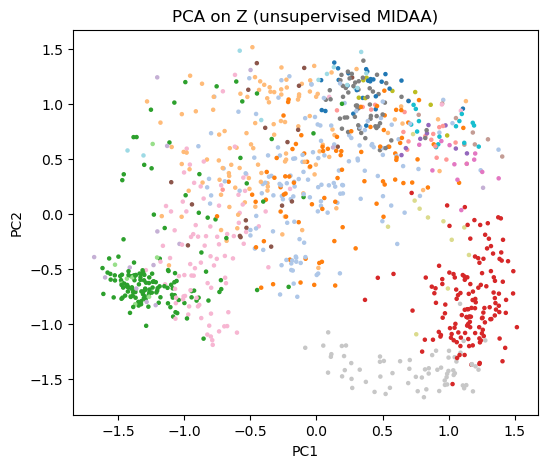

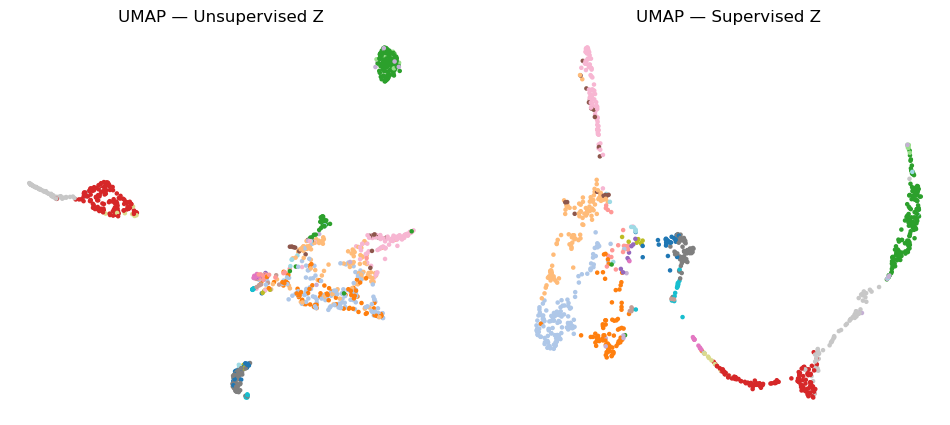

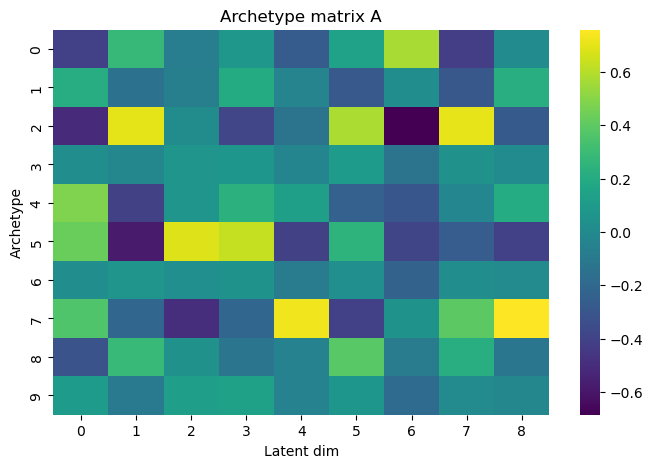

No S returned in this MIDAA version — skipping.


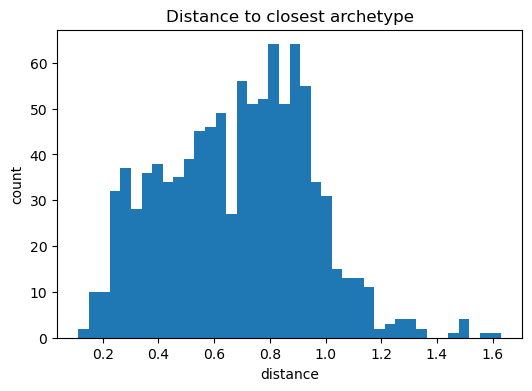

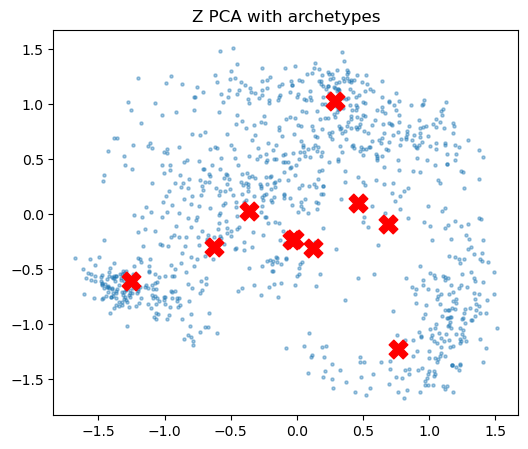

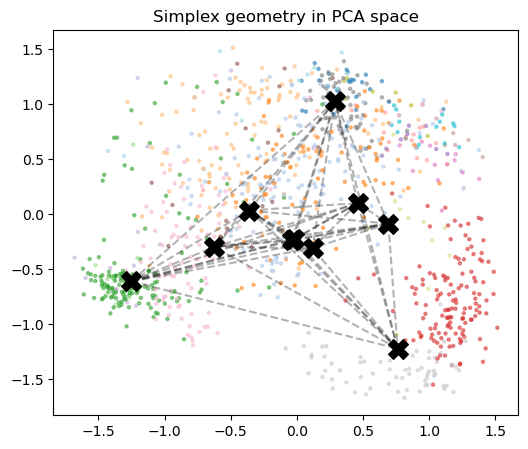

✓ SECTION 6 completed successfully.


In [16]:
# ============================================
# SECTION 6 — LATENT SPACE ANALYSIS (FIXED)
# ============================================

print("SECTION 6: Latent space analysis...")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import umap

# --------------------------------------------
# HENT VARIABLER FRA SECTION 2 + 3
# --------------------------------------------
Z = res_unsup["inferred_quantities"]["Z"]
A = res_unsup["inferred_quantities"]["archetypes_inferred"]
S = res_unsup["inferred_quantities"].get("S_inferred", None)

# Brug cell_type som label
label_key = "cell_type"

if label_key not in adata.obs.columns:
    raise KeyError(f"{label_key} findes ikke i adata.obs.")

# GØR DEN TIL CATEGORY
adata.obs["label_cat"] = adata.obs[label_key].astype("category")

# Categorical koder (0..K)
labels = adata.obs["label_cat"].cat.codes.values
label_names = list(adata.obs["label_cat"].cat.categories)

K = A.shape[0]

print("✓ Z shape:", Z.shape)
print("✓ A shape:", A.shape)
print("✓ Labels OK, #classes:", len(label_names))


# ============================================
# 1) PCA PÅ Z
# ============================================

pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, c=labels, cmap="tab20")
plt.title("PCA on Z (unsupervised MIDAA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# ============================================
# 2) UMAP SAMMENLIGNING
# ============================================

# Unsupervised UMAP (fra Section 2 eller regenerer)
try:
    Z_umap
except NameError:
    reducer = umap.UMAP(n_neighbors=30, min_dist=0.1)
    Z_umap = reducer.fit_transform(Z)

# Supervised Z
Z_sup = res_sup["inferred_quantities"]["Z"]
Z_sup_umap = reducer.fit_transform(Z_sup)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(Z_umap[:,0], Z_umap[:,1], s=5, c=labels, cmap="tab20")
plt.title("UMAP — Unsupervised Z")
plt.axis("off")

plt.subplot(1,2,2)
plt.scatter(Z_sup_umap[:,0], Z_sup_umap[:,1], s=5, c=labels, cmap="tab20")
plt.title("UMAP — Supervised Z")
plt.axis("off")

plt.show()


# ============================================
# 3) A HEATMAP
# ============================================

plt.figure(figsize=(8,5))
sns.heatmap(A, cmap="viridis")
plt.title("Archetype matrix A")
plt.xlabel("Latent dim")
plt.ylabel("Archetype")
plt.show()


# ============================================
# 4) S HEATMAP
# ============================================

if S is not None:
    plt.figure(figsize=(8,5))
    sns.heatmap(S[:200], cmap="magma")
    plt.title("S_inferred (first 200 samples)")
    plt.xlabel("Archetype")
    plt.ylabel("Sample index")
    plt.show()
else:
    print("No S returned in this MIDAA version — skipping.")


# ============================================
# 5) DISTANCE TO NEAREST ARCHETYPE
# ============================================

dists = np.sqrt(((Z[:,None,:] - A[None,:,:])**2).sum(axis=2))
min_dist = dists.min(axis=1)

plt.figure(figsize=(6,4))
plt.hist(min_dist, bins=40)
plt.title("Distance to closest archetype")
plt.xlabel("distance")
plt.ylabel("count")
plt.show()


# ============================================
# 6) PCA Z + ARCHETYPES
# ============================================

A_pca = pca.transform(A)

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, alpha=0.4)
plt.scatter(A_pca[:,0], A_pca[:,1], s=180, marker="X", c="red")
plt.title("Z PCA with archetypes")
plt.show()


# ============================================
# 7) SIMPLEX STRUCTURE I PCA-RUMMET
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(Z_pca[:,0], Z_pca[:,1], s=5, c=labels, cmap="tab20", alpha=0.5)

# forbind archetypes
for i in range(K):
    for j in range(i+1, K):
        plt.plot([A_pca[i,0], A_pca[j,0]],
                 [A_pca[i,1], A_pca[j,1]],
                 "k--", alpha=0.3)

plt.scatter(A_pca[:,0], A_pca[:,1], s=200, marker="X", c="black")
plt.title("Simplex geometry in PCA space")
plt.show()

print("✓ SECTION 6 completed successfully.")



SECTION 7: interpolation, sampling, archetype paths...
Decoder type: MLP=False, Conv1D=True
→ Running Conv1D interpolation (gene-expression curves)


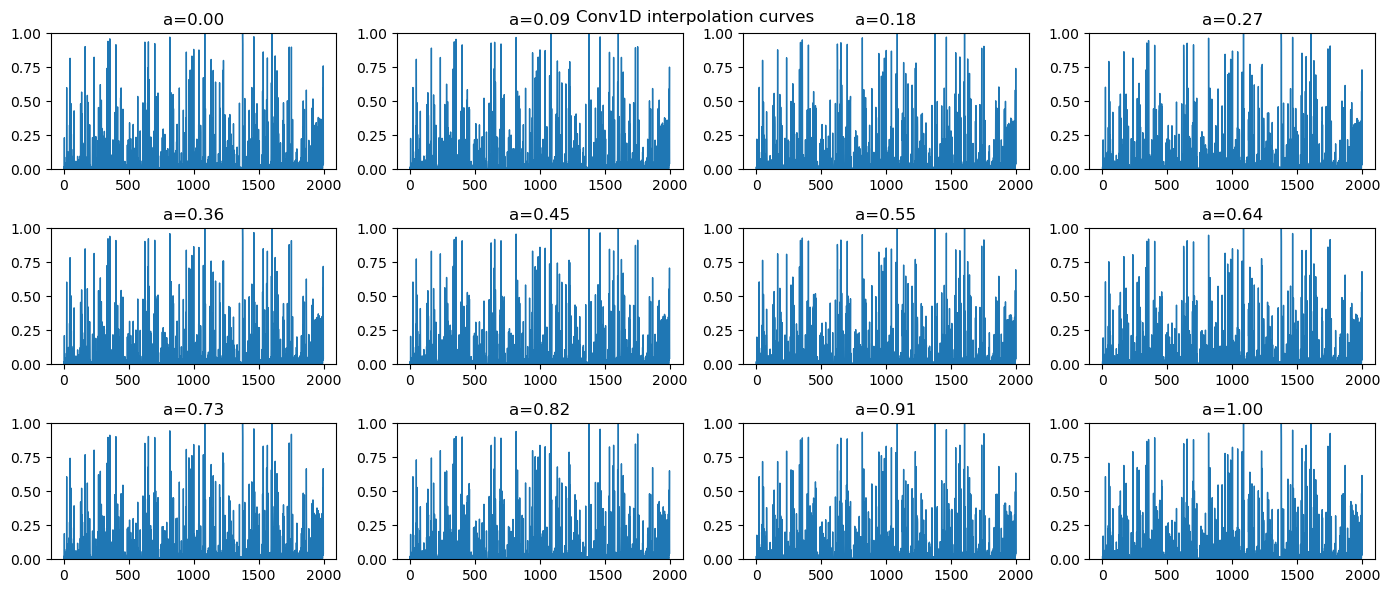

→ Archetype → archetype interpolation


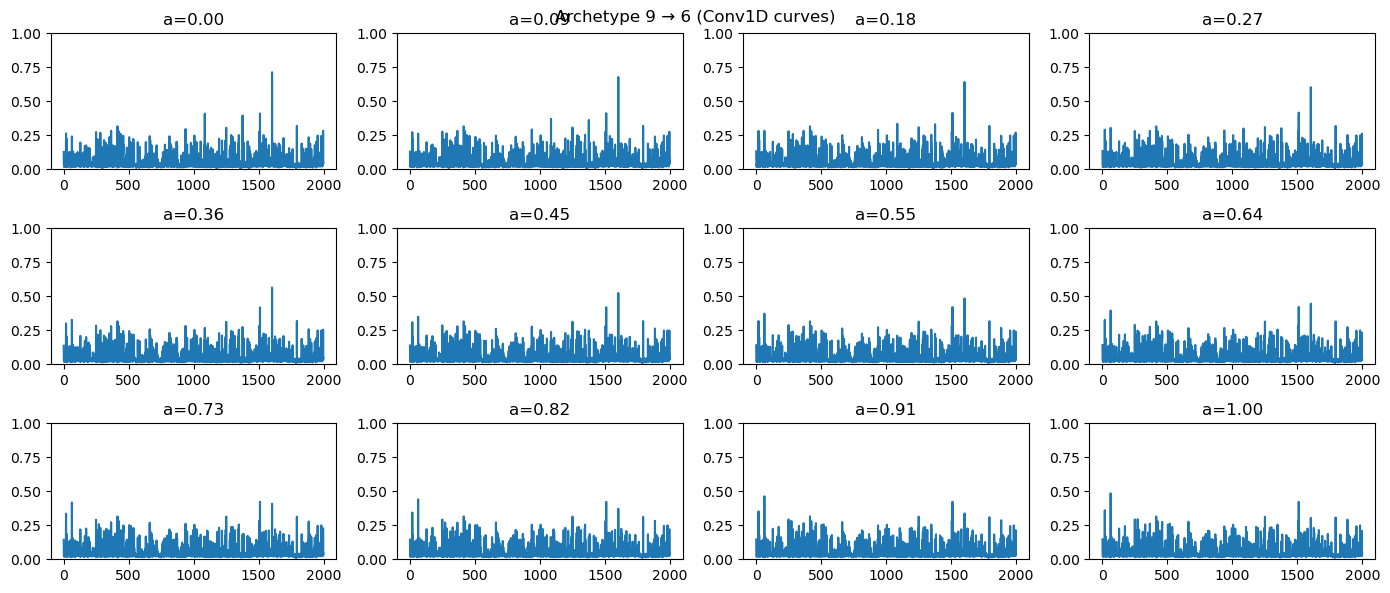

✓ SECTION 7 completed successfully.


In [18]:
# ============================================
# SECTION 7 — Interpolation, sampling, archetype paths (FIXED)
# ============================================

print("SECTION 7: interpolation, sampling, archetype paths...")

import numpy as np
import matplotlib.pyplot as plt
import torch


# ----------------------------------------------------------
# 1) Hjælpefunktion: decode afhængigt af modeltype
# ----------------------------------------------------------

def decode_any(decoder, Z_batch, is_conv=False):
    """
    Decoder-output uanset om modellen er MLP (28x28) eller Conv1D (gene expression).
    Returnerer:
       - (N,28,28)  hvis MLP
       - (N,G)      hvis Conv1D
    """
    Z_t = torch.tensor(Z_batch).float()
    out = decoder(Z_t).detach().numpy()

    if is_conv:
        # gene expression → ingen reshape
        return out  # (N, G)

    else:
        # forventer 784 → 28×28
        if out.shape[1] != 784:
            raise ValueError(
                f"MLP decode forventede 784 features (28×28), men fik {out.shape[1]}"
            )
        return out.reshape(-1, 28, 28)


# ----------------------------------------------------------
# 2) Vælg to punkter i Z (til interpolation)
# ----------------------------------------------------------

idx1 = np.random.randint(0, len(Z))
idx2 = np.random.randint(0, len(Z))

z1 = Z[idx1]
z2 = Z[idx2]

alphas = np.linspace(0, 1, 12)

Z_interp = np.array([(1 - a) * z1 + a * z2 for a in alphas])


# ----------------------------------------------------------
# 3) INTERPOLATION – MLP (hvis 784 features)
# ----------------------------------------------------------

is_mlp = hasattr(decoder, "net")    # meget robust MLP-detektor
is_conv = isinstance(decoder, Conv1DDecoder)

print(f"Decoder type: MLP={is_mlp}, Conv1D={is_conv}")

if is_mlp:
    print("→ Running MLP interpolation (28×28 images)")

    imgs = decode_any(decoder, Z_interp, is_conv=False)

    plt.figure(figsize=(15, 3))
    for i in range(len(alphas)):
        plt.subplot(1, len(alphas), i+1)
        plt.imshow(imgs[i], cmap="gray")
        plt.axis("off")
        plt.title(f"a={alphas[i]:.2f}")
    plt.suptitle("MLP interpolation")
    plt.show()


# ----------------------------------------------------------
# 4) INTERPOLATION – Conv1D (gene expression)
# ----------------------------------------------------------

if is_conv:
    print("→ Running Conv1D interpolation (gene-expression curves)")

    curves = decode_any(decoder, Z_interp, is_conv=True)

    plt.figure(figsize=(14, 6))
    for i in range(len(alphas)):
        plt.subplot(3, 4, i+1)
        plt.plot(curves[i], linewidth=1)
        plt.title(f"a={alphas[i]:.2f}")
        plt.ylim(0, 1)
        plt.tight_layout()
    plt.suptitle("Conv1D interpolation curves")
    plt.show()


# ----------------------------------------------------------
# 5) INTERPOLATION MELLEM ARCHETYPES
# ----------------------------------------------------------

print("→ Archetype → archetype interpolation")

a1 = np.random.randint(0, A.shape[0])
a2 = np.random.randint(0, A.shape[0])

Z_interp_A = np.array([(1 - a) * A[a1] + a * A[a2] for a in alphas])


if is_mlp:
    imgs_A = decode_any(decoder, Z_interp_A, is_conv=False)

    plt.figure(figsize=(15, 3))
    for i in range(len(alphas)):
        plt.subplot(1, len(alphas), i+1)
        plt.imshow(imgs_A[i], cmap="gray")
        plt.axis("off")
        plt.title(f"a={alphas[i]:.2f}")
    plt.suptitle(f"Archetype {a1} → {a2} (MLP images)")
    plt.show()

if is_conv:
    curves_A = decode_any(decoder, Z_interp_A, is_conv=True)

    plt.figure(figsize=(14, 6))
    for i in range(len(alphas)):
        plt.subplot(3, 4, i+1)
        plt.plot(curves_A[i])
        plt.title(f"a={alphas[i]:.2f}")
        plt.ylim(0,1)
        plt.tight_layout()
    plt.suptitle(f"Archetype {a1} → {a2} (Conv1D curves)")
    plt.show()


print("✓ SECTION 7 completed successfully.")


In [19]:
print("X shape:", adata.X.shape)


X shape: (1000, 2000)


X shape: (1000, 2000)


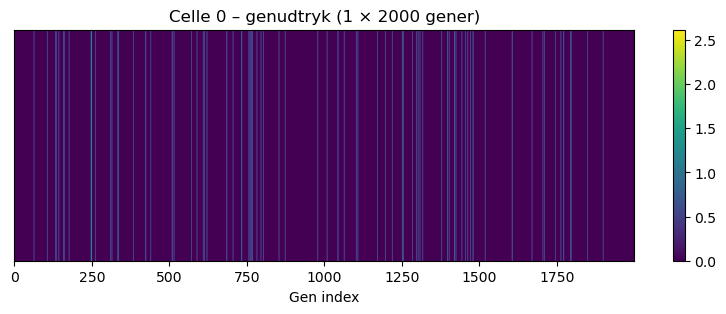

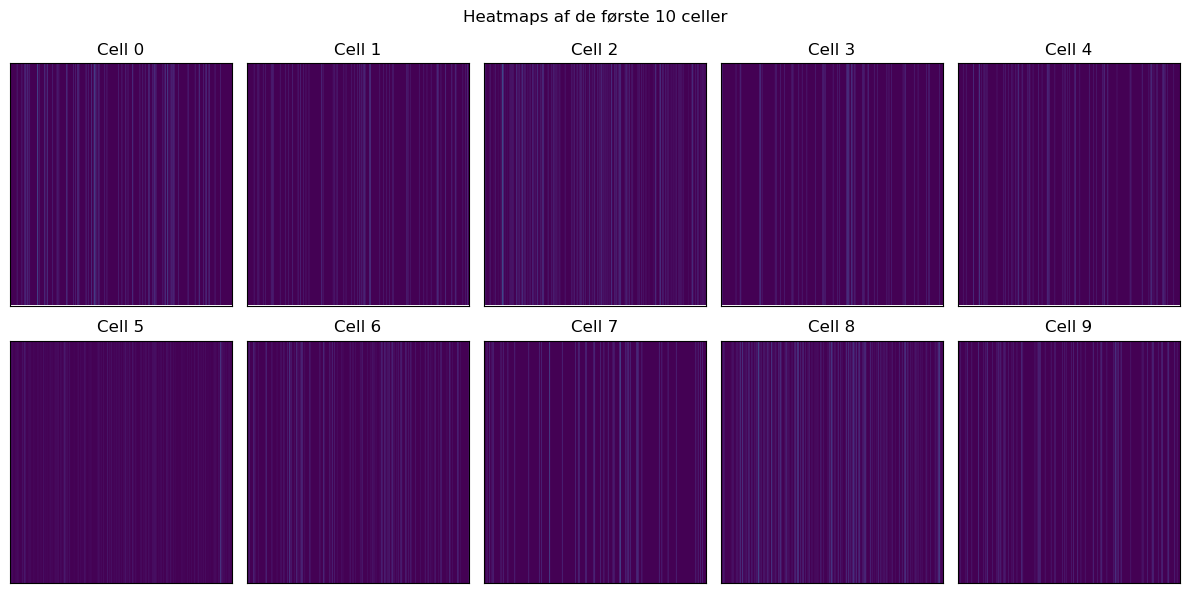

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# X = adata.X (1000 × 2000)
X = adata.X

print("X shape:", X.shape)

# ----------------------------------------
# 1) VIS ÉN CELLE SOM HEATMAP
# ----------------------------------------

idx = 0   # vælg celle index (0–999)
plt.figure(figsize=(10,3))
plt.imshow(X[idx].reshape(1, -1), aspect="auto", cmap="viridis")
plt.title(f"Celle {idx} – genudtryk (1 × 2000 gener)")
plt.xlabel("Gen index")
plt.yticks([])
plt.colorbar()
plt.show()


# ----------------------------------------
# 2) GRID MED 10 CELLER
# ----------------------------------------

plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X[i].reshape(1, -1), aspect="auto", cmap="viridis")
    plt.title(f"Cell {i}")
    plt.yticks([])
    plt.xticks([])

plt.suptitle("Heatmaps af de første 10 celler")
plt.tight_layout()
plt.show()
